In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFE
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score,confusion_matrix
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import joblib
import sklearn


In [2]:

df = pd.read_csv('cleaned_heart_data.csv')

X = df.drop('target', axis=1)
y = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Define feature types
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# 4. Set up Scikit-Learn Pipelines
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 5. Split and Process Data for ML
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
final_categorical = ['cp', 'thal','chol','oldpeak','thalach','exang','slope']
X_final_subset = X[final_categorical]

X_train_final, X_test_final, y_train, y_test = train_test_split(
    X_final_subset, y, test_size=0.2, random_state=42, stratify=y
)

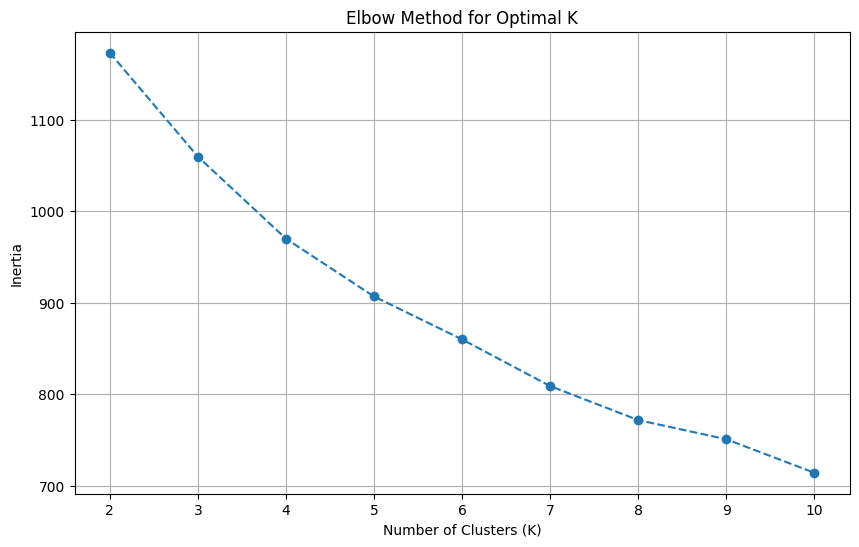

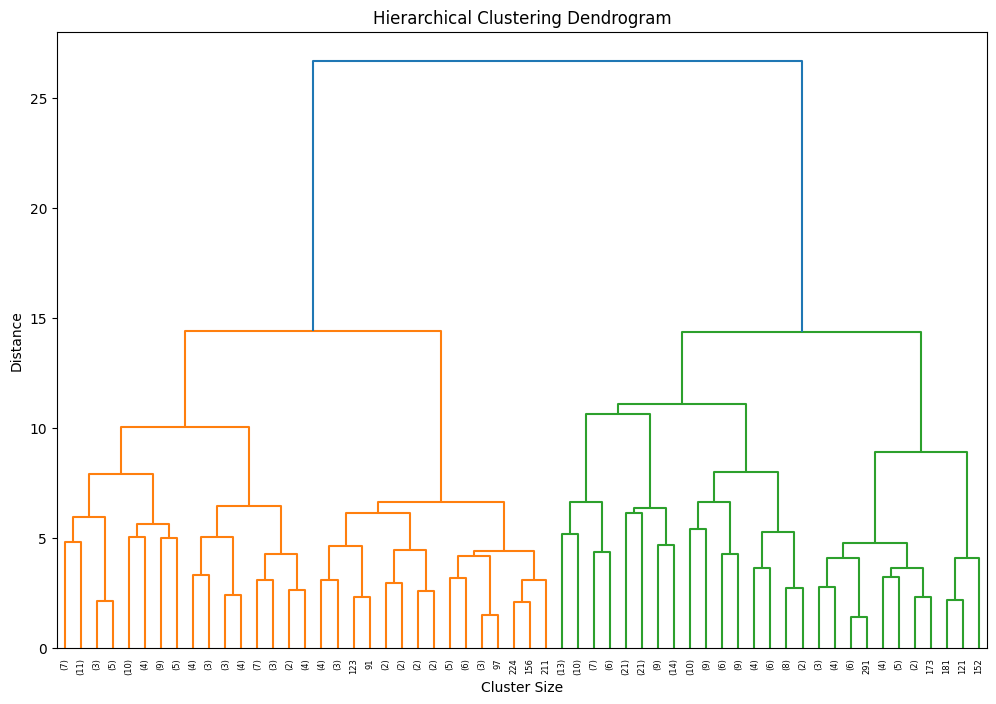

--- K-Means Clustering Results (K=2) ---
Silhouette Score: 0.25

Cross-Tabulation with Actual Labels:
col_0     0   1
target         
0       141  23
1        42  97


--- Hierarchical Clustering Results (n=2) ---
Silhouette Score: 0.22

Cross-Tabulation with Actual Labels:
col_0    0    1
target         
0       28  136
1       91   48


In [3]:
selected_numerical_features = [f for f in numerical_features if f in final_categorical]
selected_categorical_features = [f for f in categorical_features if f in final_categorical]




preprocessor_full = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, selected_numerical_features),
        ('cat', categorical_transformer, selected_categorical_features)
    ])


X_processed = preprocessor_full.fit_transform(X_final_subset)



inertia_values = []
k_range = range(2, 11) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X_processed)
    inertia_values.append(kmeans.inertia_)


plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()




linked = linkage(X_processed, method='ward')


plt.figure(figsize=(12, 8))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           truncate_mode='level',
           p=5) 
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.show()





kmeans_final = KMeans(n_clusters=2, n_init='auto', random_state=42)
kmeans_labels = kmeans_final.fit_predict(X_processed)
kmeans_crosstab = pd.crosstab(y, kmeans_labels)
kmeans_silhouette = silhouette_score(X_processed, kmeans_labels)

print("--- K-Means Clustering Results (K=2) ---")
print("Silhouette Score:", round(kmeans_silhouette, 2))
print("\nCross-Tabulation with Actual Labels:")
print(kmeans_crosstab)
print("\n")



agg_cluster = AgglomerativeClustering(n_clusters=2)
agg_labels = agg_cluster.fit_predict(X_processed)
agg_crosstab = pd.crosstab(y, agg_labels)
agg_silhouette = silhouette_score(X_processed, agg_labels)

print("--- Hierarchical Clustering Results (n=2) ---")
print("Silhouette Score:", round(agg_silhouette, 2))
print("\nCross-Tabulation with Actual Labels:")
print(agg_crosstab)